# S3 TALLER BUSQUEDA INFORMADA

# Celda 1: Preparación del Entorno y Datos
## Configuramos nuestro mapa de la montaña y las estimaciones de tiempo.

In [1]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Grafo con tiempos de viaje en minutos (g)
mapa_montana = {
  'Campamento Base': {'Paso Rocoso': 30, 'Puente Colgante': 20},
  'Paso Rocoso': {'Cascada': 60},
  'Puente Colgante': {'Cascada': 40, 'Cueva': 50},
  'Cascada': {'Refugio': 70},
  'Cueva': {'Refugio': 60},
  'Refugio': {}
}

# Tiempo estimado hasta el Refugio (heurística h)
heuristica_tiempo = {
  'Campamento Base': 100, 
  'Paso Rocoso': 60,
  'Puente Colgante': 80, 
  'Cascada': 50,
  'Cueva': 40, 
  'Refugio': 0
}

# Celda 2: Algoritmos de Búsqueda
## Los motores lógicos para nuestro equipo de rescate.

In [2]:
# --- Búsqueda Voraz Primero el Mejor (Greedy) ---
def greedy_best_first(graph, start, goal, heuristics):
    priority_queue = [(heuristics[start], [start])]
    visited = set()
    
    while priority_queue:
        _, path = heapq.heappop(priority_queue)
        node = path[-1]
        
        if node in visited: continue
        visited.add(node)
        
        if node == goal: return path
        
        for neighbor in graph[node]:
            if neighbor not in visited:
                heapq.heappush(priority_queue, (heuristics[neighbor], path + [neighbor]))
    return None

# --- Búsqueda A* (A-Estrella) ---
def a_star_search(graph, start, goal, heuristics):
    priority_queue = [(0 + heuristics[start], 0, [start])]
    visited = set()
    
    while priority_queue:
        f, g, path = heapq.heappop(priority_queue)
        node = path[-1]
        
        if node in visited: continue
        visited.add(node)
        
        if node == goal: return path, g
        
        for neighbor, cost in graph[node].items():
            if neighbor not in visited:
                new_g = g + cost
                new_f = new_g + heuristics[neighbor]
                heapq.heappush(priority_queue, (new_f, new_g, path + [neighbor]))
    return None, -1

# Celda 3: Ejecución de la Misión
## Llamamos a los algoritmos y comparamos los planes de rescate.

In [3]:
origen = 'Campamento Base'
destino = 'Refugio'

# Plan del rescatista inexperto (Greedy)
ruta_greedy = greedy_best_first(mapa_montana, origen, destino, heuristica_tiempo)
# Calculamos el costo manual de esta ruta para el reporte
costo_greedy = 30 + 60 + 70 # Campamento -> Paso Rocoso -> Cascada -> Refugio

print("⚠️ PLAN VORAZ (Greedy)")
print(f"Ruta tomada: {ruta_greedy}")
print(f"Tiempo Total Estimado: {costo_greedy} minutos")
print("-" * 40)

# Plan del rescatista experto (A*)
ruta_a_star, costo_total_a_star = a_star_search(mapa_montana, origen, destino, heuristica_tiempo)

print("🚁 PLAN ÓPTIMO (A*)")
print(f"Ruta tomada: {ruta_a_star}")
print(f"Tiempo Total Real: {costo_total_a_star} minutos")

⚠️ PLAN VORAZ (Greedy)
Ruta tomada: ['Campamento Base', 'Paso Rocoso', 'Cascada', 'Refugio']
Tiempo Total Estimado: 160 minutos
----------------------------------------
🚁 PLAN ÓPTIMO (A*)
Ruta tomada: ['Campamento Base', 'Puente Colgante', 'Cascada', 'Refugio']
Tiempo Total Real: 130 minutos


# Celda 4: Visualización Táctica del Rescate
## Graficamos la montaña, mostrando los tiempos, la heurística y resaltando la ruta ganadora.

/tmp/ipykernel_38131/506963758.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


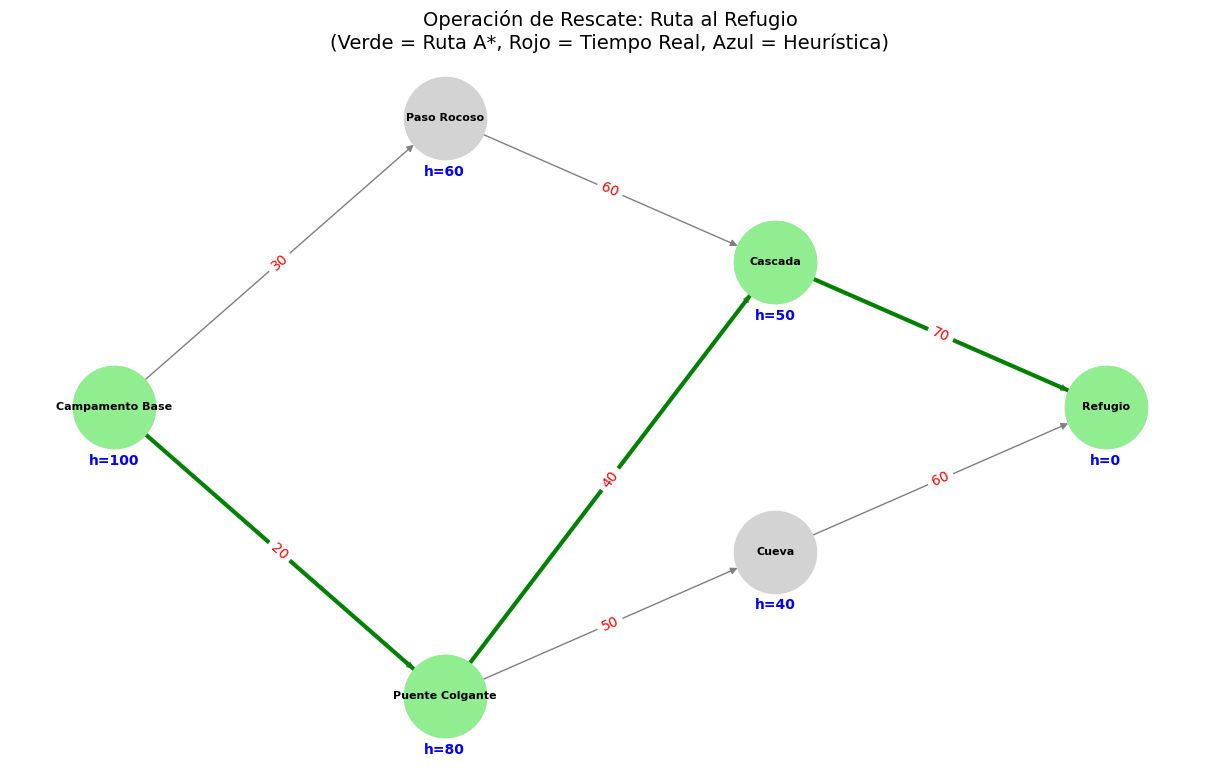

In [4]:
# Crear el grafo dirigido
G = nx.DiGraph()

# Poblar el grafo con los datos
for nodo_origen, destinos in mapa_montana.items():
    for nodo_destino, costo in destinos.items():
        G.add_edge(nodo_origen, nodo_destino, weight=costo)

# Configurar el lienzo
plt.figure(figsize=(12, 7))

# Layout del mapa de montaña
posiciones = {
    'Campamento Base': (0, 1),
    'Paso Rocoso': (1, 2),
    'Puente Colgante': (1, 0),
    'Cascada': (2, 1.5),
    'Cueva': (2, 0.5),
    'Refugio': (3, 1)
}

# 1. Dibujar nodos y aristas base
nx.draw(G, posiciones, with_labels=True, node_color='lightgray', node_size=3500, 
        font_size=8, font_weight='bold', edge_color='gray', arrows=True)

# 2. Resaltar la ruta óptima de A* (en verde)
if ruta_a_star:
    aristas_a_star = [(ruta_a_star[i], ruta_a_star[i+1]) for i in range(len(ruta_a_star)-1)]
    nx.draw_networkx_nodes(G, posiciones, nodelist=ruta_a_star, node_color='lightgreen', node_size=3500)
    nx.draw_networkx_edges(G, posiciones, edgelist=aristas_a_star, edge_color='green', width=3, arrows=True)

# 3. Etiquetas de los tiempos de viaje (en rojo)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, posiciones, edge_labels=edge_labels, font_color='red')

# 4. Etiquetas de la heurística (en azul)
for nodo, (x, y) in posiciones.items():
    h_val = heuristica_tiempo[nodo]
    plt.text(x, y - 0.2, s=f"h={h_val}", color='blue', fontweight='bold', horizontalalignment='center')

plt.title("Operación de Rescate: Ruta al Refugio\n(Verde = Ruta A*, Rojo = Tiempo Real, Azul = Heurística)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Reporte de Misión

## 1. ¿Qué ruta encontró el algoritmo Greedy Best-First y cuál fue su costo total en minutos?

- **Ruta:**  
  `['Campamento Base', 'Paso Rocoso', 'Cascada', 'Refugio']`

- **Tiempo total:**  
  **160 minutos** (30 + 60 + 70)

---

## 2. ¿Qué ruta encontró el algoritmo A* y cuál fue su costo total?

- **Ruta:**  
  `['Campamento Base', 'Puente Colgante', 'Cascada', 'Refugio']`

> **Nota:**  
> Técnicamente, ir por la *'Cueva'* también toma exactamente **130 minutos**, por lo que A* podría arrojar cualquiera de las dos dependiendo de cómo Python resuelva el empate interno en la cola de prioridad.

- **Tiempo total:**  
  **130 minutos** (20 + 40 + 70)

---

## 3. ¿Por qué el algoritmo voraz se equivocó (si lo hizo)? ¿Qué información ignoró?

El algoritmo voraz se equivocó porque fue engañado por el **"espejismo" del atajo**.

- Desde el *Campamento Base*, evaluó únicamente la heurística:
  - Paso Rocoso: **h = 60**
  - Puente Colgante: **h = 80**

- Eligió el nodo que parecía más cercano a la meta, **ignorando completamente el costo acumulado** (tiempo real recorrido).

- Como resultado:
  - Terminó en rutas más lentas (ej. Paso Rocoso → Cascada = 60 min)
  - Tomó una decisión **localmente óptima pero globalmente subóptima**

---

## 4. En una situación de rescate real, ¿por qué es CRUCIAL usar un algoritmo óptimo como A* en lugar de uno simplemente voraz?

Porque en una emergencia:

- Los recursos son **limitados y críticos**:
  - Tiempo  
  - Combustible  
  - Oxígeno  

- En este caso:
  - Algoritmo voraz: **160 minutos**
  - A*: **130 minutos**
  - **Se pierden 30 minutos valiosos**

### Ventaja de A*

A* evalúa el problema de forma **integral**:

- **Costo real acumulado (g)** → lo que ya se ha gastado  
- **Heurística (h)** → lo que se estima que falta  

**f(n) = g(n) + h(n)**

Esto garantiza que:

> Se encuentre la ruta óptima (la de menor costo total)